<a href="https://colab.research.google.com/github/hariharan-vs/24ADI003---24BAD030/blob/main/ML_LAB_EXP_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hariharan V S - 24BAD030
   userId  movieId  rating    timestamp
0       1        1     4.0  964982703.0
1       1        3     4.0  964981247.0
2       1        6     4.0  964982224.0
3       1       47     5.0  964983815.0
4       1       50     5.0  964982931.0
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
RMSE: 1.7372914719747008
MAE: 1.2038670311810613
      movieId                 title  \
506       588        Aladdin (1992)   
902      1200

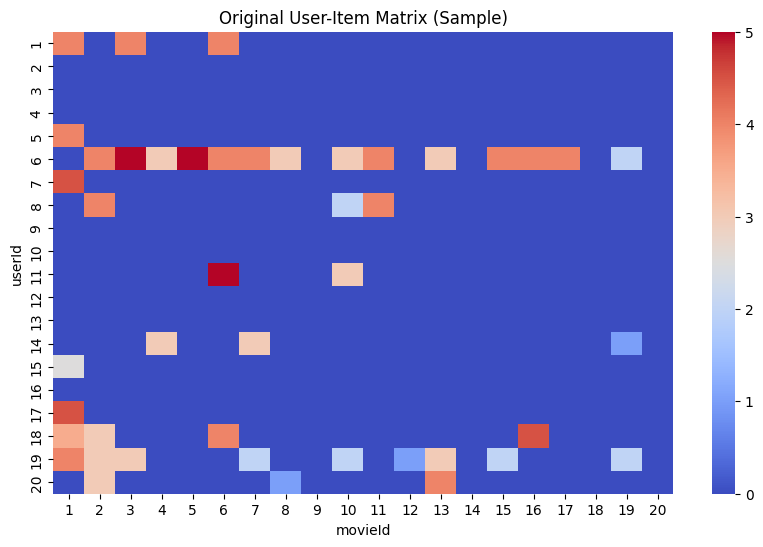

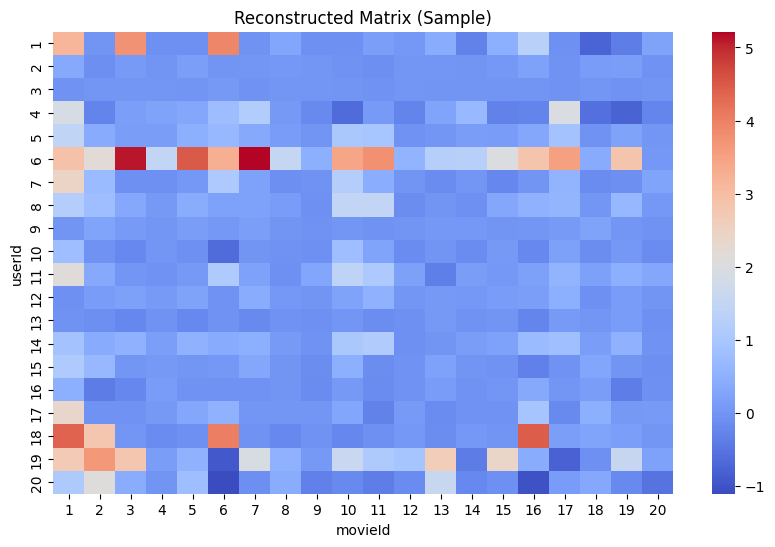

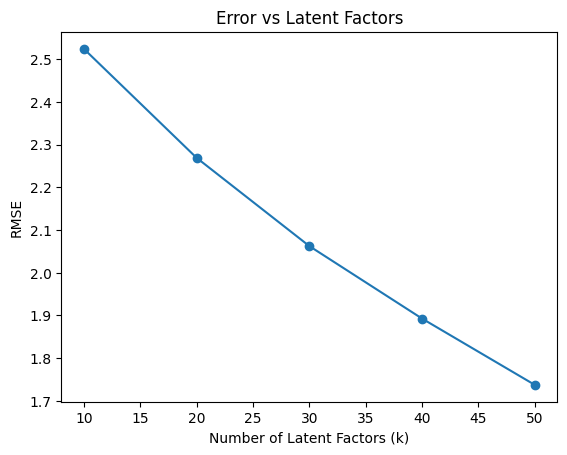

In [ ]:
print("Hariharan V S - 24BAD030")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.sparse.linalg import svds

ratings = pd.read_csv('/content/ratings.csv')
movies = pd.read_csv('/content/movies.csv')

print(ratings.head())
print(movies.head())

df = pd.merge(ratings, movies, on='movieId')

user_item_matrix = df.pivot_table(index='userId', columns='movieId', values='rating')

user_item_matrix_filled = user_item_matrix.fillna(0)

R = user_item_matrix_filled.values

user_ratings_mean = np.mean(R, axis=1)
R_demeaned = R - user_ratings_mean.reshape(-1, 1)

train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42)

k = 50

U, sigma, Vt = svds(R_demeaned, k=k)

sigma = np.diag(sigma)

R_pred = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)

pred_df = pd.DataFrame(R_pred, columns=user_item_matrix.columns, index=user_item_matrix.index)

def get_pred_rating(user, movie):
    return pred_df.loc[user, movie]

y_true = []
y_pred = []

for row in test_data.itertuples():
    try:
        pred = pred_df.loc[row.userId, row.movieId]
        y_true.append(row.rating)
        y_pred.append(pred)
    except:
        continue

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

def recommend_movies(user_id, num_recommendations=10):
    user_row = pred_df.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index

    recommendations = user_row.drop(already_rated)
    top_movies = recommendations.sort_values(ascending=False).head(num_recommendations)

    return movies[movies['movieId'].isin(top_movies.index)]

print(recommend_movies(user_id=1, num_recommendations=5))

plt.figure(figsize=(10, 6))
sns.heatmap(user_item_matrix_filled.iloc[:20, :20], cmap='coolwarm')
plt.title("Original User-Item Matrix (Sample)")
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(pred_df.iloc[:20, :20], cmap='coolwarm')
plt.title("Reconstructed Matrix (Sample)")
plt.show()

k_values = [10, 20, 30, 40, 50]
rmse_list = []

for k in k_values:
    U, sigma, Vt = svds(R_demeaned, k=k)
    sigma = np.diag(sigma)
    R_pred = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)

    pred_df_temp = pd.DataFrame(R_pred, columns=user_item_matrix.columns, index=user_item_matrix.index)

    y_pred_temp = []
    y_true_temp = []

    for row in test_data.itertuples():
        try:
            pred = pred_df_temp.loc[row.userId, row.movieId]
            y_true_temp.append(row.rating)
            y_pred_temp.append(pred)
        except:
            continue

    rmse_temp = np.sqrt(mean_squared_error(y_true_temp, y_pred_temp))
    rmse_list.append(rmse_temp)

plt.figure()
plt.plot(k_values, rmse_list, marker='o')
plt.xlabel("Number of Latent Factors (k)")
plt.ylabel("RMSE")
plt.title("Error vs Latent Factors")
plt.show()

Hariharan V S - 24BAD030
RMSE: 1.1242108486309577
Precision@10: 0.5383606557377049
Recall@10: 0.11020939693742869
     movieId                                      title  \
31        32  Twelve Monkeys (a.k.a. 12 Monkeys) (1995)   
507      589          Terminator 2: Judgment Day (1991)   
659      858                      Godfather, The (1972)   
793     1036                            Die Hard (1988)   
902     1200                              Aliens (1986)   

                             genres  
31          Mystery|Sci-Fi|Thriller  
507                   Action|Sci-Fi  
659                     Crime|Drama  
793           Action|Crime|Thriller  
902  Action|Adventure|Horror|Sci-Fi  


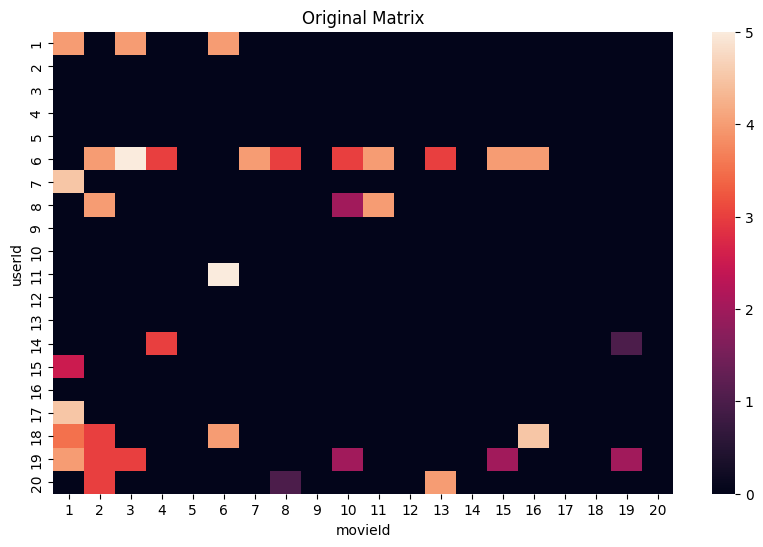

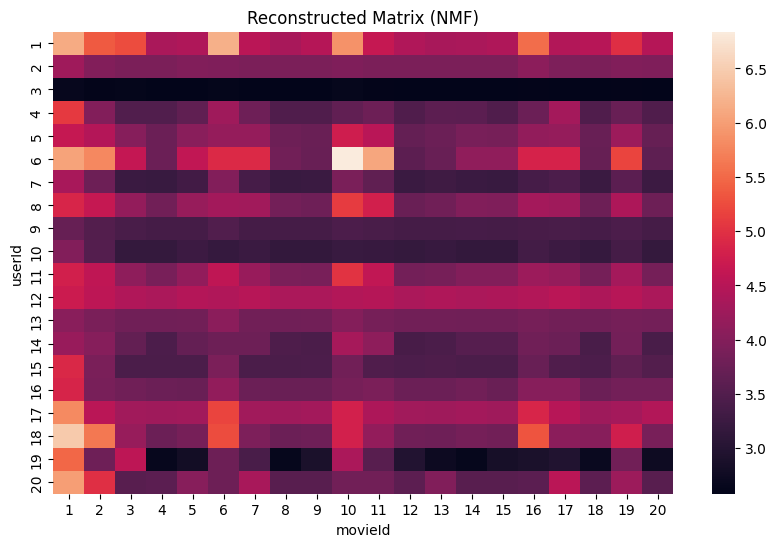

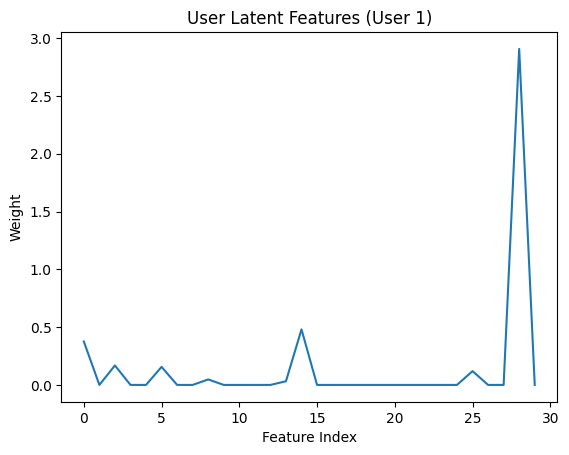

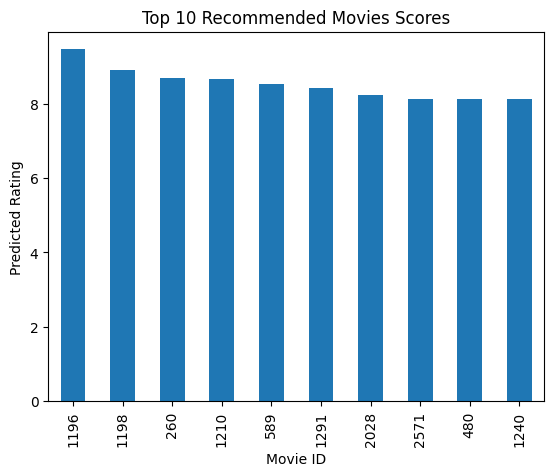

In [ ]:
print("Hariharan V S - 24BAD030")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

ratings = pd.read_csv('/content/ratings.csv')
movies = pd.read_csv('/content/movies.csv')

train, test = train_test_split(ratings, test_size=0.2, random_state=42)

train_matrix = train.pivot_table(index='userId', columns='movieId', values='rating')

train_filled = train_matrix.fillna(0)
R = train_filled.values

k = 30

nmf_model = NMF(n_components=k, init='nndsvd', random_state=42, max_iter=500)

W = nmf_model.fit_transform(R)
H = nmf_model.components_

R_pred = np.dot(W, H)

pred_df = pd.DataFrame(R_pred, columns=train_matrix.columns, index=train_matrix.index)

pred_df = pred_df.add(user_mean, axis=0)

y_true = []
y_pred = []

for row in test.itertuples():
    if row.userId in pred_df.index and row.movieId in pred_df.columns:
        pred = pred_df.loc[row.userId, row.movieId]
        pred = min(5, max(0.5, pred))
        y_true.append(row.rating)
        y_pred.append(pred)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("RMSE:", rmse)

def precision_recall_at_k(pred_df, original_df, k=10, threshold=3.5):
    precisions = []
    recalls = []
    for user in pred_df.index:
        if user not in original_df.index:
            continue
        pred_ratings = pred_df.loc[user].sort_values(ascending=False)
        top_k = pred_ratings.head(k).index
        actual_ratings = original_df.loc[user].dropna()
        relevant = actual_ratings[actual_ratings >= threshold].index
        recommended_relevant = set(top_k).intersection(set(relevant))
        precision = len(recommended_relevant) / k if k > 0 else 0
        recall = len(recommended_relevant) / len(relevant) if len(relevant) > 0 else 0
        precisions.append(precision)
        recalls.append(recall)
    return np.mean(precisions), np.mean(recalls)

full_matrix = ratings.pivot_table(index='userId', columns='movieId', values='rating')

precision, recall = precision_recall_at_k(pred_df, full_matrix, k=10)

print("Precision@10:", precision)
print("Recall@10:", recall)

def recommend_movies(user_id, num_recommendations=10):
    user_ratings = full_matrix.loc[user_id]
    already_rated = user_ratings.dropna().index
    recommendations = pred_df.loc[user_id].drop(already_rated)
    top_movies = recommendations.sort_values(ascending=False).head(num_recommendations)
    return movies[movies['movieId'].isin(top_movies.index)]

print(recommend_movies(user_id=1, num_recommendations=5))

plt.figure(figsize=(10, 6))
sns.heatmap(train_filled.iloc[:20, :20])
plt.title("Original Matrix")
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(pred_df.iloc[:20, :20])
plt.title("Reconstructed Matrix (NMF)")
plt.show()

plt.figure()
plt.plot(W[0])
plt.title("User Latent Features (User 1)")
plt.xlabel("Feature Index")
plt.ylabel("Weight")
plt.show()

user_id = 1
recommended = pred_df.loc[user_id].sort_values(ascending=False).head(10)

plt.figure()
recommended.plot(kind='bar')
plt.title("Top 10 Recommended Movies Scores")
plt.xlabel("Movie ID")
plt.ylabel("Predicted Rating")
plt.show()